# 🏥 Lab 6: X-Ray Physics Simulation
## Attenuation, Noise, and Contrast

**AI in Medicine and Healthcare**  
**Insper Instituto de Ensino e Pesquisa**  
**Week 4 - Class 6**

---

## 📝 Student Information (REQUIRED)

**Student 1:**
- Name: Rodrigo Medeiros
- Email: rodrigopm6@al.insper.edu.br

**Student 2:**
- Name: Gabriel Hermida
- Email: gabrielmmh@al.insper.edu.br

**Date Submitted:** 03/03/2026

---

### Objectives
1. ✅ Implement Beer-Lambert Law
2. ✅ Simulate Poisson noise
3. ✅ Apply contrast agents

In [7]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

%matplotlib inline
np.random.seed(42)

print('✓ Libraries loaded!')

✓ Libraries loaded!


## PART 0: Load Datasets

We'll use synthetic datasets to simulate the X-ray attenutation.

In [8]:
# Download and extract dataset
!gdown 1xWdAUKYQMETttyJj9b_htOq9U4BdaJOT
!unzip -q xray_test_images.zip

print("✓ Dataset ready!")

Downloading...
From: https://drive.google.com/uc?id=1xWdAUKYQMETttyJj9b_htOq9U4BdaJOT
To: /content/xray_test_images.zip
100% 659k/659k [00:00<00:00, 82.8MB/s]
replace test_images/angio_phantom.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test_images/hand_phantom.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test_images/vessel_mask.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test_images/chest_phantom.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace test_images/phantom_simple.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: [n]
error:  invalid response [[n]]
replace test_images/phantom_simple.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace __MACOSX/test_images/._phantom_simple.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test_images/angio_phantom.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace __MACOSX/test_images/._angio_phantom.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test_images/attenuation_reference.txt? [y]es, [n]o, [A]ll, [N]one

In [9]:
# Load test images
phantom_simple = np.load('test_images/phantom_simple.npy')
hand_phantom = np.load('test_images/hand_phantom.npy')
chest_phantom = np.load('test_images/chest_phantom.npy')
angio_phantom = np.load('test_images/angio_phantom.npy')
vessel_mask = np.load('test_images/vessel_mask.npy')

print(f'Loaded {phantom_simple.shape}, {hand_phantom.shape}, {chest_phantom.shape}')

Loaded (256, 256), (300, 250), (400, 350)


---
## PART 1: Beer-Lambert Law

**Formula:** $I = I_0 \cdot e^{-\mu x}$

- $I_0$ = incident intensity
- $\mu$ = attenuation coefficient (cm⁻¹)
- $x$ = path length (cm)

In [10]:
# TODO: Implement Beer-Lambert Law
def beer_lambert(I0, mu, x):
    """
    Calculate transmitted X-ray intensity.

    Parameters:
    - I0: incident intensity
    - mu: attenuation coefficient (cm^-1)
    - x: path length (cm)

    Returns:
    - I: transmitted intensity
    """
    I = I0 * np.exp(-mu * x)

    return I

# Test your function
print('Testing Beer-Lambert:')
print(f'  Air (mu=0.0):   {beer_lambert(1.0, 0.0, 10.0):.4f}')
print(f'  Tissue (mu=0.2): {beer_lambert(1.0, 0.2, 10.0):.4f}')
print(f'  Bone (mu=0.5):  {beer_lambert(1.0, 0.5, 10.0):.4f}')

Testing Beer-Lambert:
  Air (mu=0.0):   1.0000
  Tissue (mu=0.2): 0.1353
  Bone (mu=0.5):  0.0067


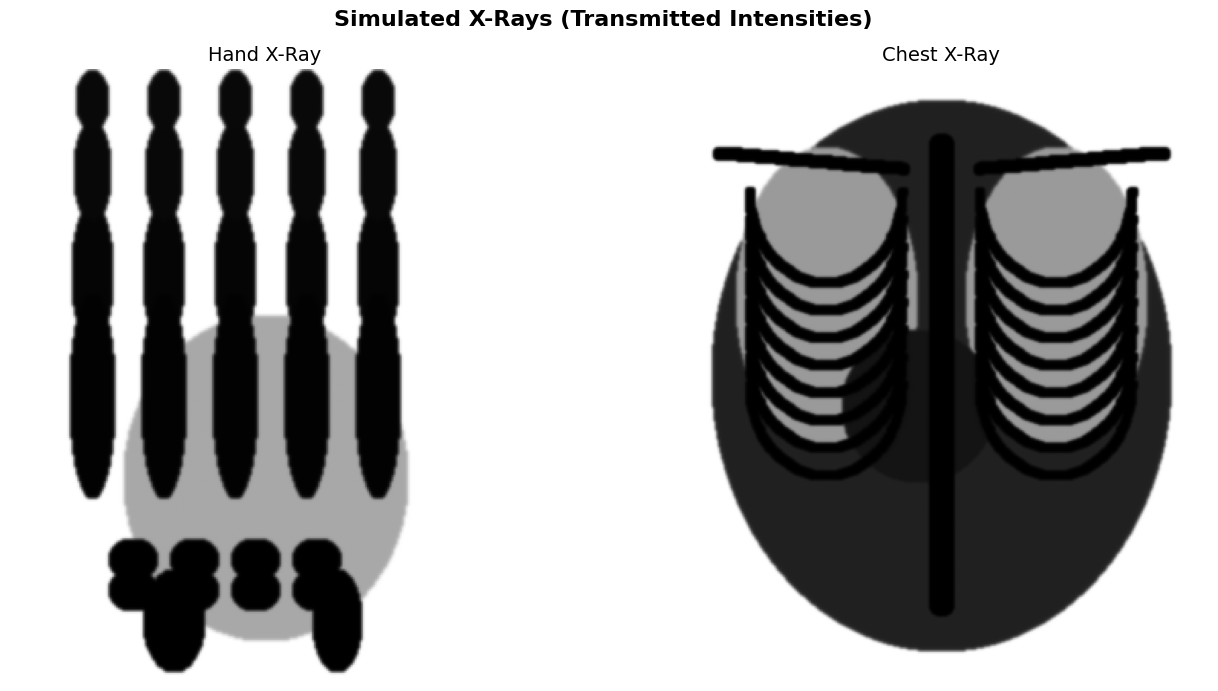

In [12]:
# TODO: Create X-ray projection
def create_xray_image(attenuation_map, I0=1000, thickness=10):
    """
    Convert attenuation map to X-ray image.

    Parameters:
    - attenuation_map: 2D array of mu values
    - I0: incident intensity
    - thickness: tissue thickness (cm)

    Returns:
    - xray_image: simulated X-ray
    """
    # TODO: Apply Beer-Lambert to each pixel
    xray = [I0 * np.exp(-mu * thickness) for mu in attenuation_map]

    return xray

# Test
xray_hand = create_xray_image(hand_phantom)
xray_chest = create_xray_image(chest_phantom)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(xray_hand, cmap='gray')
axes[0].set_title('Hand X-Ray', fontsize=14)
axes[0].axis('off')

axes[1].imshow(xray_chest, cmap='gray')
axes[1].set_title('Chest X-Ray', fontsize=14)
axes[1].axis('off')

plt.suptitle('Simulated X-Rays (Transmitted Intensities)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## PART 2: Quantum Mottle (Noise)

X-rays follow **Poisson statistics**:
- Few photons → High noise
- Many photons → Low noise (but higher dose!)

In [13]:
# Add Poisson noise (quantum mottle)
def add_poisson_noise(image, photon_count=1000):
    """
    Add quantum mottle to X-ray image.

    Parameters:
    - image: X-ray image (normalized 0-1)
    - photon_count: average photons per pixel

    Returns:
    - noisy_image: image with Poisson noise
    """
    # 1. Scale image by photon_count
    scaled = image * photon_count

    # 2. Apply Poisson sampling (each pixel drawn from Poisson(λ=scaled_value))
    noisy = np.random.poisson(scaled)

    # 3. Scale back to original range
    noisy = noisy / photon_count

    return noisy

# Compare different dose levels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
doses = [100, 1000, 5000]

for i, dose in enumerate(doses):
    noisy = add_poisson_noise(xray_hand, dose)
    axes[i].imshow(noisy, cmap='gray')
    axes[i].set_title(f'Dose: {dose} photons', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Dose vs Image Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f47682ef6a0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f47682ecc20> (for post_execute):


KeyboardInterrupt: 

---
## PART 3: Contrast Agents

Blood vessels are **invisible** (same μ as tissue)!

**Solution:** Inject iodine (Z=53, μ=2.0 cm⁻¹)

In [ ]:
# X-ray WITHOUT contrast
xray_before = create_xray_image(angio_phantom)

plt.figure(figsize=(10, 10))
plt.imshow(xray_before, cmap='gray')
plt.title('Angiography WITHOUT Contrast\nVessels are invisible!', fontsize=14)
plt.axis('off')
plt.show()

print('❌ Blood vessels not visible - same attenuation as tissue')

In [ ]:
# TODO: Inject iodine contrast
def inject_contrast(attenuation_map, vessel_mask, mu_iodine=2.0):
    """
    Simulate contrast agent injection.

    Parameters:
    - attenuation_map: original mu values
    - vessel_mask: boolean mask of vessels
    - mu_iodine: iodine attenuation

    Returns:
    - enhanced_map: map with contrast in vessels
    """
    # TODO: Set vessel pixels to iodine attenuation
    enhanced = None

    return enhanced

# Apply contrast
angio_with_contrast = inject_contrast(angio_phantom, vessel_mask)
xray_after = create_xray_image(angio_with_contrast)

# Compare before and after
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(xray_before, cmap='gray')
axes[0].set_title('BEFORE Contrast', fontsize=14)
axes[0].axis('off')

axes[1].imshow(xray_after, cmap='gray')
axes[1].set_title('AFTER Iodine Injection', fontsize=14)
axes[1].axis('off')

plt.suptitle('Angiography with Contrast Agent', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Vessels now visible with iodine contrast!')

---
## Reflection Questions

**Q1:** Why do bones appear white in clinical X-rays?

**Your answer:** _______________

**Q2:** What is the trade-off between radiation dose and image quality?

**Your answer:** _______________

**Q3:** Why do we need contrast agents for angiography?

**Your answer:** _______________

**Q4:** How does this lab prepare you for CT reconstruction ?

**Your answer:** _______________